## Importing libraries

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import powerlaw
import itertools
from networkx.algorithms.community import girvan_newman, modularity
from pprint import pprint as pp
from sklearn.preprocessing import MinMaxScaler
from scipy import signal
from scipy.spatial.distance import squareform, pdist
import seaborn as sns

## Reading the data and plotting a basic graph

In [2]:
# ---+ reading the data
G = nx.read_graphml('trading_floor.xml')
#G.nodes(data=True)

(-1.1780533586232393,
 1.126742469926363,
 -1.1837307252171114,
 1.2075038245681418)

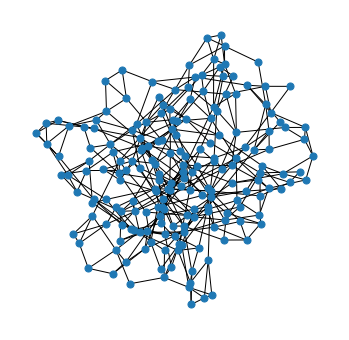

In [3]:
# initial visualisation of the graph
fig = plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G)
nx.draw_networkx(G, 
        pos=(pos), 
        node_size=50,
        with_labels=False)
plt.axis("off")

## Calculating degree statistics for the network

In [4]:
# ---+ getting statistics on degree distribution
dv = dict(G.degree())
dd = list(dv.values())
print("""
==============================================
    Summary stats on degree distribution
==============================================
Mu    :       {:.3f}
Min   :       {:>5}
Max   :       {:>5}
Sigma :       {:.3f}
""".format(np.mean(dd),
           np.min(dd),
           np.max(dd),
           np.std(dd))
     )


    Summary stats on degree distribution
Mu    :       4.000
Min   :           2
Max   :           7
Sigma :       0.901



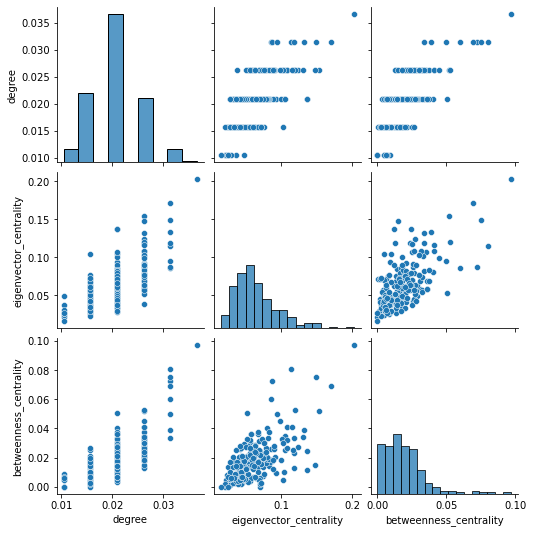

In [5]:
# ---+ calculating centrality metrics
# degree
degree = nx.degree_centrality(G)
# eigenvector_centrality
ec = nx.eigenvector_centrality(G)
# betweeness centrality
bc = nx.betweenness_centrality(G)
# visualising results
# creating a dataframe
cm_df = pd.DataFrame({'degree': degree,
                     'eigenvector_centrality': ec,
                   'betweenness_centrality': bc}
                   )

# --+ correlation matrix
cm_df.corr()
# --+ scatter plot matrix
sns.pairplot(cm_df)

Calculating best minimal value for power law fit


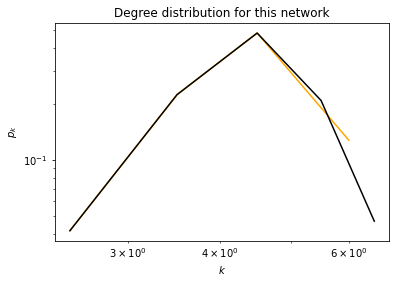

In [6]:
# node degree
node_degree = nx.degree(G)
# data series to plot
x = [d for n, d in node_degree]

# fit powerlaw
fit = powerlaw.Fit(x)
alpha = fit.power_law.alpha
sigma = fit.power_law.sigma
cmp = fit.distribution_compare('power_law', 'exponential')


fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)

powerlaw.plot_pdf(x, 
                  color='orange', 
                  ax=ax)
powerlaw.plot_pdf(x, 
                  linear_bins=True, 
                  color='black', 
                  ax=ax)

ax.set_title("Degree distribution for this network")
ax.set_ylabel(r"$p_{k}$")
ax.set_xlabel(r"$k$")

plt.show()

In [7]:
print("The number of connected components in the network are " + str(nx.number_connected_components(G)) + ".")

The number of connected components in the network are 1.


## Visualising the distribution of preferences across the trading floor

In [8]:
# ---+ creating a dataframe of the attributes of the different nodes
attr_df = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient='index')
attr_df['pos']=tuple(zip(*attr_df[['x_pos','y_pos']].values.T))
scaler = MinMaxScaler()
attr_df['ai_scaled'] = scaler.fit_transform(attr_df[['ai']])
#attr_df #(visualisation)

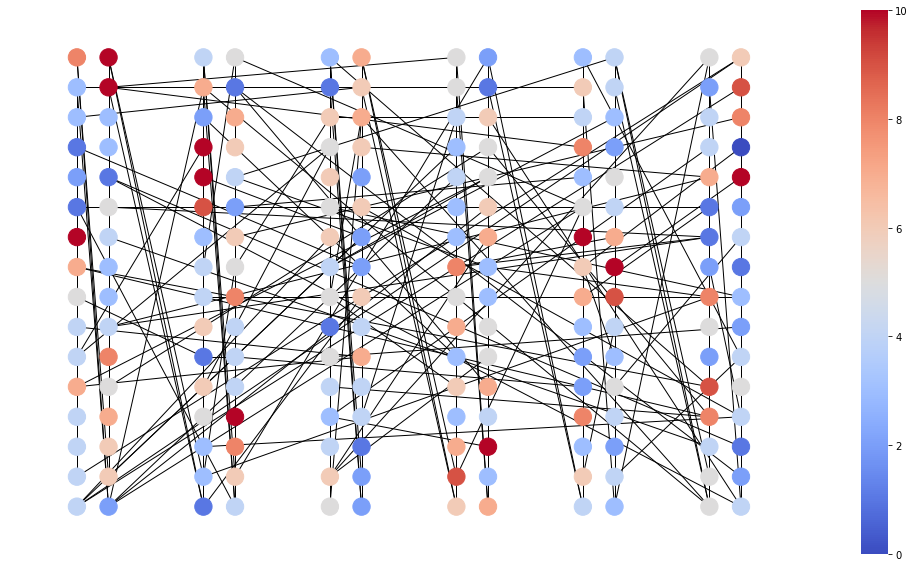

In [9]:
# ---+ plotting the network of traders by their position on the floor and visualising their preference to AI

plt.figure(figsize=(18,10))
vmax = attr_df['ai'].max()
vmin = attr_df['ai'].min()

nx.draw_networkx(G,
                 pos=attr_df['pos'],
                 node_color=attr_df['ai'],
                 with_labels=False,
                 cmap='coolwarm',
                 edge_color="k")

c_b = plt.cm.ScalarMappable(cmap='coolwarm',
                           norm=plt.Normalize(vmin=vmin, vmax=vmax))
plt.axis('off')
cbar = plt.colorbar(c_b)
cbar.outline.set_visible(False)
plt.show()

## Visualising the communitites on the trading floor

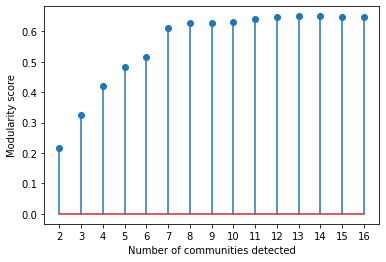

In [10]:
# ---+ using the modularity score to view the number of communities present on the trading floor
solutions = girvan_newman(G)
k = 15
modularity_scores = dict()
# iterating over solutions
for community in itertools.islice(solutions, k):
    solution = list(sorted(c) for c in community)
    score = modularity(G, solution)
    modularity_scores[len(solution)] = score

# plotting modularity data
fig = plt.figure()
pos = list(modularity_scores.keys())
values = list(modularity_scores.values())
ax = fig.add_subplot(1, 1, 1)
ax.stem(pos, values)
ax.set_xticks(pos)
ax.set_xlabel(r'Number of communities detected')
ax.set_ylabel(r'Modularity score')
plt.show()

In [11]:
# ---+ fitting the Girvman-Newman algorithm on 13 communities (optimal modularity)

# retrieving the solution of 13 communities
solutions = girvan_newman(G)
tuple(sorted(c) for c in next(solutions))
solutions = girvan_newman(G)

k = 12
for community in itertools.islice(solutions, k):
    coms = (list(sorted(c) for c in community))

In [12]:
# ---+ assigining the communities from the soultion to the Girvan-Newman algorithm to the nodes they belong to
comms_no = []
comms_list = []
for i in coms:
    for j in i:
        comms_no.append(coms.index(i))
        comms_list.append(j)

# creating a dataframe assigining communities to the nodes        
comms_df = pd.DataFrame({'Nodes':list(map(int, comms_list)), 'Community':comms_no})
comms_df.sort_values('Nodes', inplace=True)
comms_df.reset_index(inplace=True)
comms_df.drop('index', axis=1, inplace=True)
#comms_df #(visualisation)

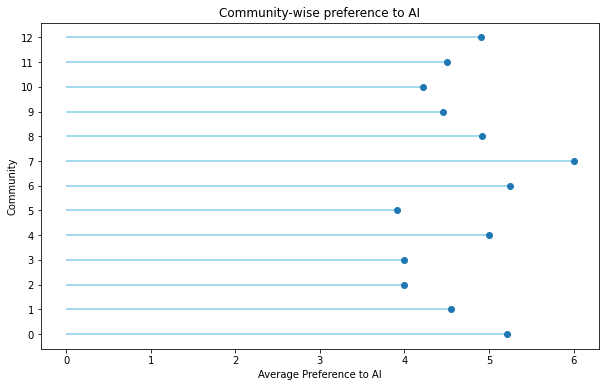

In [13]:
# ---+ calulating average preference by community
comms_df['AI'] = attr_df['ai'].to_numpy()
comms_pref = comms_df.groupby('Community')['AI'].mean()


# visualising the result
my_range=range(1,len(comms_pref.index)+1)
plt.figure(figsize=(10,6))

plt.hlines(y=my_range, 
           xmin=0, 
           xmax=comms_pref, 
           color='skyblue')
plt.plot(comms_pref, 
         my_range, 
         "o")
 
plt.yticks(my_range, comms_pref.index)
plt.title("Community-wise preference to AI")
plt.xlabel('Average Preference to AI')
plt.ylabel('Community')

plt.show()

In [14]:
x_pos_list = attr_df['x_pos']
y_pos_list = attr_df['y_pos']
pos1 = dict(list(zip(G.nodes().keys(), zip(x_pos_list.apply(lambda x: x + 0.35), y_pos_list.apply(lambda x: x + 0.5)))))
for node, a in zip(G.nodes, comms_df['Community']):
    G.nodes[node]["Community"] = a

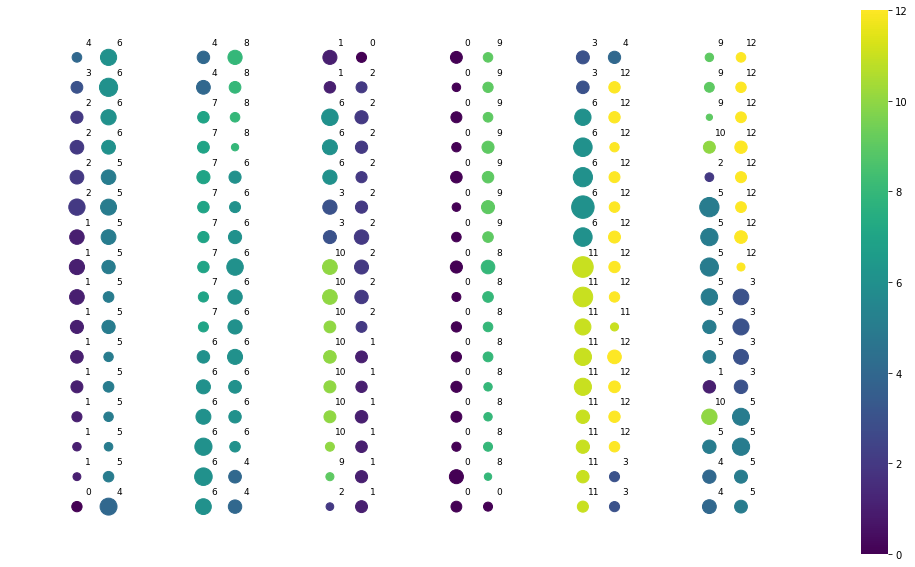

In [25]:
# ---+ visualising the traders of the floor by their respective communities and distinguishing them by their eigenvector centralities 
#      (how influential are the nodes they are connected to)
fig = plt.figure(figsize=(18,10))
vmax1 = max(comms_df['Community'])
vmin1 = min(comms_df['Community'])
nx.draw_networkx(G,
                 pos=attr_df['pos'],
                 node_color=comms_df['Community'],
                 node_size=cm_df['eigenvector_centrality']*2500,
                 with_labels=False,
                 edge_color = 'w')
nx.draw_networkx_labels(G,
                        pos=pos1,
                        labels = nx.get_node_attributes(G, 'Community'),
                        font_color='k',
                        font_size=9)

c_b1 = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin1, vmax=vmax1))

plt.axis('off')
cbar1 = plt.colorbar(c_b1)
cbar1.outline.set_visible(False)
plt.show()

## Does the position of traders (proximity) explain their preference to AI

In [16]:
# ---+ Calculating the similarity of the trader's preferences towards AI
mat = attr_df.loc[:,['ai', 'pos']]
simi_mat = abs(mat['ai'].values - mat['ai'].values[:, None])
simi_df=pd.DataFrame(data=simi_mat[0:,0:],
        index=[i for i in range(simi_mat.shape[0])],
        columns=[i for i in range(simi_mat.shape[1])])
#simi_df #(visualisation)

In [17]:
# ---+ Calculating the physical distance between the traders
mat1 = attr_df.loc[:,['x_pos', 'y_pos']]
mat1.reset_index(inplace=True)
mat1.rename(columns={"index": "node"}, inplace=True)
close_df = pd.DataFrame(squareform(pdist(mat1.iloc[:, 1:],
                                    metric='euclidean')), 
                        columns=mat1.node.unique(),
                        index=mat1.node.unique())
#close_df #(visualisation)

In [18]:
# ---+ Calculating the correlation between trader's position and their preferences
def corr(df1, df2):
    n = len(df1)
    v1, v2 = df1.values, df2.values
    sums = np.multiply.outer(v2.sum(0), v1.sum(0))
    stds = np.multiply.outer(v2.std(0), v1.std(0))
    return pd.DataFrame((v2.T.dot(v1) - sums / n) / stds / n,
                        df2.columns, df1.columns)
cor_df = corr(simi_df,close_df)
print("The maximum correlation between the proximity of traders and their preference to AI is " + str(cor_df.to_numpy().max()) + ".")

The maximum correlation between the proximity of traders and their preference to AI is 0.2033298412779513.


## Implementing Easley and Kleinberg's diffusion model on the traders

In [19]:
# ---+ creating a dataframe of attributes that explain the diffusion of positive opinion of AI among the traders
payoff_df = attr_df.drop(['ai', 'x_pos', 'y_pos', 'pos'], axis=1)
payoff_df['ec'] = scaler.fit_transform(cm_df[['eigenvector_centrality']])
#payoff_df #(visualisation)

In [20]:
# ---+ defining the difussion function using Easley and Kleinberg's diffusion model
def diffusion(thres):
    # defining early adopters at the initial state
    # the ones most likely to spread positive opinion about AI are those with high preference toward it
    attr_df["Adopters"] = (attr_df["ai"] >= thres).astype(int)

    # reflecting the decision to adopt as an attribute
    a = attr_df['Adopters']
    for i in sorted(G.nodes()):
       G.nodes[i]['adopting'] = a[i]

    # setting colors for the different nodes
    colors = []
    for n in G.nodes():
        if G.nodes[n]['adopting'] == 1:
            colors.append('limegreen')
        else:
            colors.append('#EE3B3B')

    # visualising the early adopters
    fig = plt.figure(figsize=(30,10))
    ax1 = fig.add_subplot(1,2,1)
    ax1.set_title('Early Adopters at threshold = ' + str(thres),
                    fontsize=25)
    nx.draw_networkx(G,
                     pos=attr_df['pos'],
                     edge_color='k', 
                     with_labels=False,
                     node_color=colors,
                     cmap=plt.cm.coolwarm,
                     alpha=0.95, ax=ax1)
    ax1.axis('off')
    

    # modelling the diffusion process
    for focal in G.nodes:
        # likelihood of adopting a more positive opinion of AI as a function of their existing preference to AI and their eigenvector centrality (scaled)
        a = ((payoff_df['ai_scaled'].iloc[int(focal)]) * payoff_df['ec'].iloc[int(focal)])
        # likelihood resisting the spread of positive opinion towards AI
        b = ((1-payoff_df['ai_scaled'].iloc[int(focal)]) * payoff_df['ec'].iloc[int(focal)])
        # counting the adopting neighbors
        focal_nbrs = list(G.neighbors(focal))
        p = np.sum([G.nodes[nbr]['adopting'] for nbr in focal_nbrs])
        d = G.degree(focal)
        # pay-off of adopting new behavior
        a_payoff = p * a
        b_payoff = (d - p) * b
        # reflecting the diffusion process
        if (G.nodes[focal]['adopting'] == 0) & (a_payoff > b_payoff):
            G.nodes[focal]['adopting'] = 1
        else:
            pass

    # setting colors for the different nodes
    colors = []
    for n in G.nodes():
        if G.nodes[n]['adopting'] == 1:
            colors.append('limegreen')
        else:
            colors.append('#EE3B3B')

    # visualising the spread of positive opinion
    ax2 = fig.add_subplot(1,2,2)
    ax2.set_title('Diffusion at threshold = ' + str(thres),
                   fontsize=25)
    nx.draw_networkx(G,
                     pos=attr_df['pos'],
                     edge_color='k', 
                     with_labels=False,
                     node_color=colors,
                     cmap=plt.cm.coolwarm,
                     alpha=0.95,
                     ax=ax2)
    ax2.axis('off')
    plt.show()

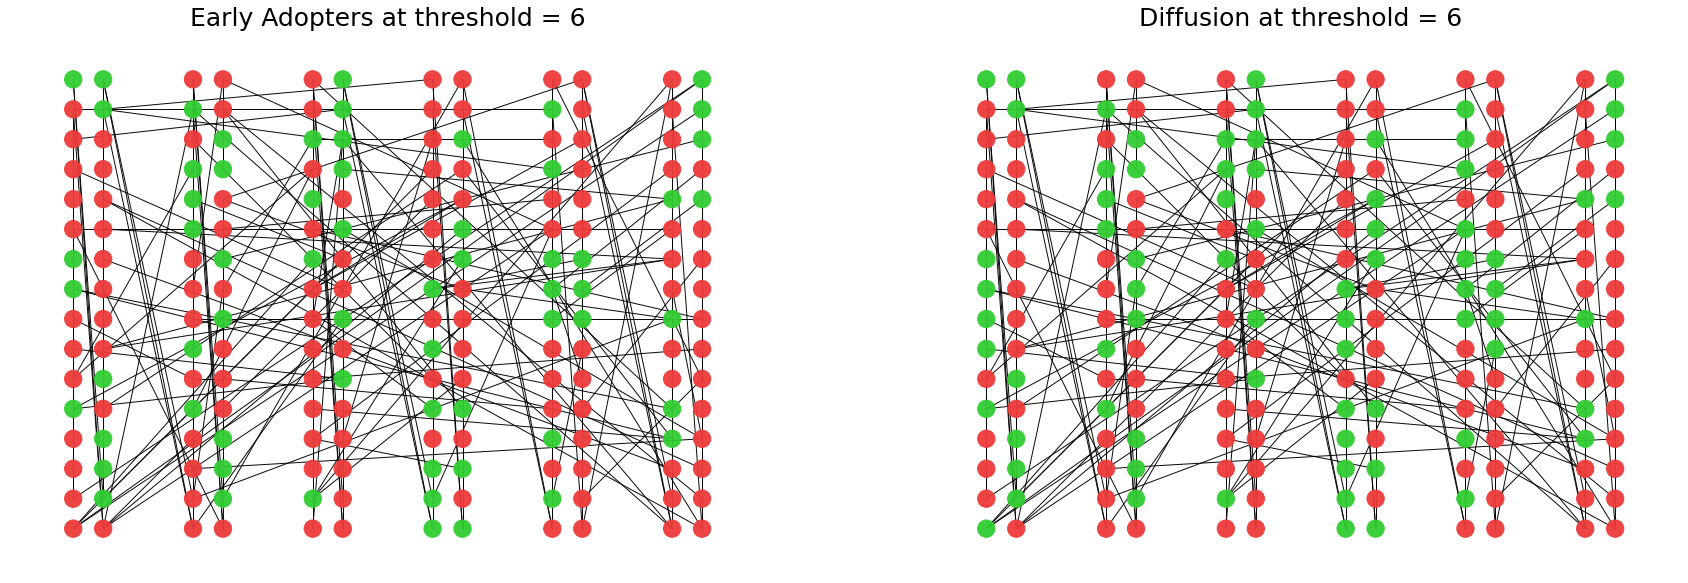

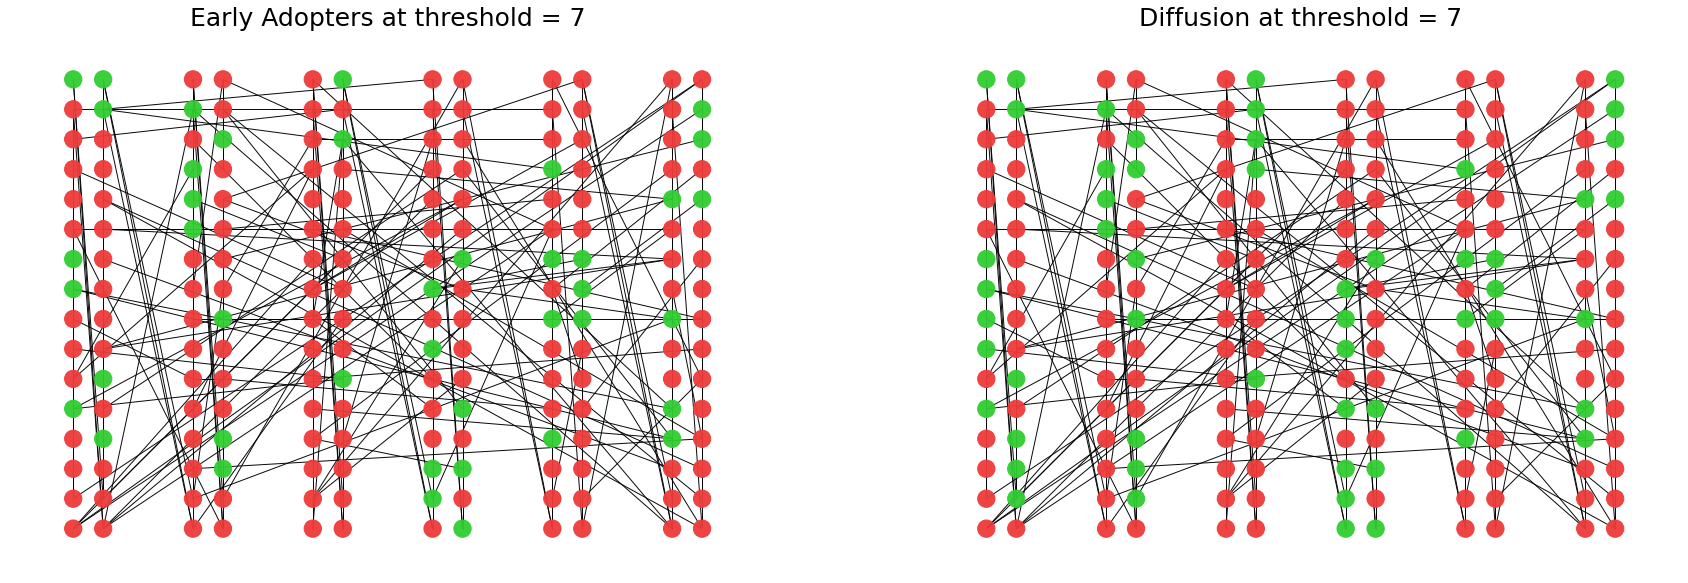

In [21]:
# ---+ running the diffusion function to visualise the spread of positive opinion towards AI
diffusion(6)
diffusion(7)
#diffusion(8)
#diffusion(9)

In [22]:
# ---+ calculating the percentage of traders who have developed positive opinion towards AI
adopt_dict = nx.get_node_attributes(G, 'adopting')
adopt = []
for i in adopt_dict.values():
    adopt.append(i)

print(str(round(np.mean(adopt) * 100)) + "% of the traders have a positive opinion towards AI.")

28% of the traders have a positive opinion towards AI.
